In [1]:
import numpy as np
import pandas as pd
import sys, os, warnings, logging, random
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

In [2]:
MODEL_DIR = "models_eas"

In [3]:
INPUT_COLS = [
    "magnitude",
    "dip",
    "ztor",
    "vs30",
    "z2p5_preferred",
    "rrup"
]

# Period / frequency / column mapping
EAS_OUTPUTS = [
    {"period": 19.952621, "freq": 0.050119,   "col": "eas(0p050118730Hz)"},
    {"period": 15.135609, "freq": 0.066069,   "col": "eas(0p066069360Hz)"},
    {"period": 12.302620, "freq": 0.081284,   "col": "eas(0p081283050Hz)"},
    {"period": 10.000000, "freq": 0.100000,   "col": "eas(0p100000000Hz)"},
    {"period": 7.413102,  "freq": 0.134896,   "col": "eas(0p134896300Hz)"},
    {"period": 4.897788,  "freq": 0.204174,   "col": "eas(0p204173800Hz)"},
    {"period": 3.981072,  "freq": 0.251189,   "col": "eas(0p251188600Hz)"},
    {"period": 3.019952,  "freq": 0.331131,   "col": "eas(0p331131100Hz)"},
    {"period": 1.995262,  "freq": 0.501187,   "col": "eas(0p501187200Hz)"},
    {"period": 1.479108,  "freq": 0.676083,   "col": "eas(0p676083000Hz)"},
    {"period": 1.000000,  "freq": 1.000000,   "col": "eas(1p000000000Hz)"},
    {"period": 0.741310,  "freq": 1.348963,   "col": "eas(1p348963000Hz)"},
    {"period": 0.489779,  "freq": 2.041738,   "col": "eas(2p041738000Hz)"},
    {"period": 0.398107,  "freq": 2.511886,   "col": "eas(2p511886300Hz)"},
    {"period": 0.301995,  "freq": 3.311311,   "col": "eas(3p311311000Hz)"},
    {"period": 0.245471,  "freq": 4.073803,   "col": "eas(4p073803000Hz)"},
    {"period": 0.199526,  "freq": 5.011872,   "col": "eas(5p011872000Hz)"},
    {"period": 0.151356,  "freq": 6.606934,   "col": "eas(6p606934000Hz)"},
    {"period": 0.100000,  "freq": 10.000000,  "col": "eas(10p000000000Hz)"},
    {"period": 0.074131,  "freq": 13.489624,  "col": "eas(13p489624000Hz)"},
    {"period": 0.048978,  "freq": 20.417380,  "col": "eas(20p417380000Hz)"},
    {"period": 0.030200,  "freq": 33.113110,  "col": "eas(33p113110000Hz)"}
]


# All EAS columns used together as multi-output target
OUT_COLS = [e["col"] for e in EAS_OUTPUTS]

freqs = np.array([spec["freq"] for spec in EAS_OUTPUTS])

In [4]:
colors     = ['b', 'g', 'r', 'm', 'c', 'y']
line_styles = ["-.", "--", ":", "-",'-.','--']

GMM_styles = {
    "This study":  {"style": "-",  "lw": 4, "marker": "d"},
    "Parker":      {"style": "-",  "lw": 2, "marker": "o"},
    "Abrahamson":  {"style": "--", "lw": 2, "marker": "s"},
    "CB25":        {"style": "-.", "lw": 2, "marker": "x"},
    "Nico":        {"style": ":",  "lw": 2, "marker": "*"},
}

In [5]:
# ======================================================
# 1) Define a single reference scenario for comparison
# ======================================================

# Rupture / site scenario (EDIT THESE if you want a different case)
ZTOR_REF   = 5.0     # km, depth to top of rupture
VS30_REF   = 400.0   # m/s, site condition (this study’s ANN choice)
DIP_REF    = 90.0    # degrees
Z2P5_REF   = 0.5     # km, depth to Vs=2.5 km/s (or equivalent)

# Response Spectra

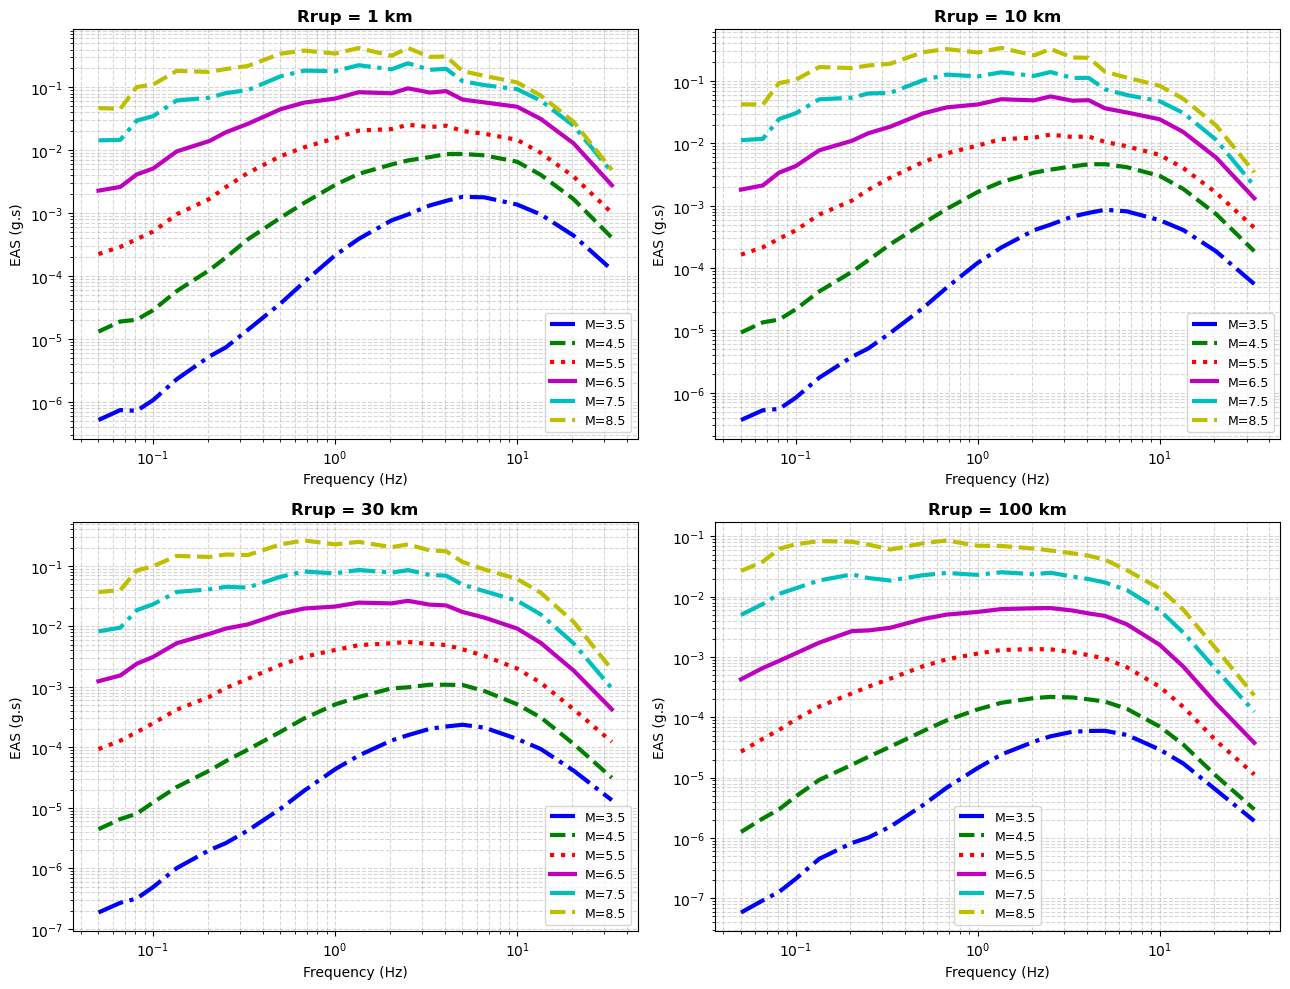

In [7]:
# ----------------------------------------------------------
# Spectrum plot settings
# ----------------------------------------------------------
magnitudes = [3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
distances  = [1, 10, 30, 100]


# Paths for the multi-output model + scaler
model_path  = os.path.join(MODEL_DIR, "Farhad_MultiFreq.keras")
scaler_path = os.path.join(MODEL_DIR, "Farhad_MultiFreq_scaler.joblib")

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Missing multi-output model: {model_path}")

if not os.path.exists(scaler_path):
    raise FileNotFoundError(f"Missing multi-output scaler: {scaler_path}")

# Load single multi-output model and single scaler
model  = load_model(model_path, compile=False)
scaler = joblib.load(scaler_path)

# Sort frequencies and remember the sort order
order = np.argsort(freqs)
freqs_sorted = freqs[order]

# ----------------------------------------------------------
# Start plotting spectra
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, Rrup in zip(axes, distances):

    for (M, color, ls) in zip(magnitudes, colors, line_styles):

        # Build single 1x6 input vector
        X = np.array([[M, DIP_REF, ZTOR_REF, VS30_REF, Z2P5_REF, Rrup]])

        # --- Apply the same transformations used during training ---
        # vs30_log = np.log(vs30)
        # rrup_log = np.log(Rrup)
        # z2p5_log = np.log1p(z2p5)   # safe for zero
        
        # # Build transformed input vector
        # X = np.array([[M, dip, ztor, vs30_log, z2p5_log, rrup_log]])

        # Predict for all frequencies at once with the multi-output model
        X_scaled = scaler.transform(X)

        # NOTE: model predicts ln(EAS) for ALL freqs → shape (1, n_freq)
        pred_ln_vec = model.predict(X_scaled, verbose=0)[0, :]   # (n_freq,)
        preds_vec   = np.exp(pred_ln_vec)                        # back to EAS

        # Sort predictions consistently with sorted freqs
        preds_sorted = preds_vec[order]

        ax.loglog(freqs_sorted, preds_sorted, ls, color=color, linewidth=3, label=f"M={M}")

    ax.set_title(f"Rrup = {Rrup} km", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("EAS (g.s)")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()


fig.savefig('EAS spectra.pdf', bbox_inches="tight")
fig.savefig('EAS spectra.png', bbox_inches="tight", dpi=300)

# EAS vs Distance

Requested freq 0.2 Hz; using nearest freq 0.204174 Hz (index 5)
Requested freq 5.0 Hz; using nearest freq 5.011872 Hz (index 16)


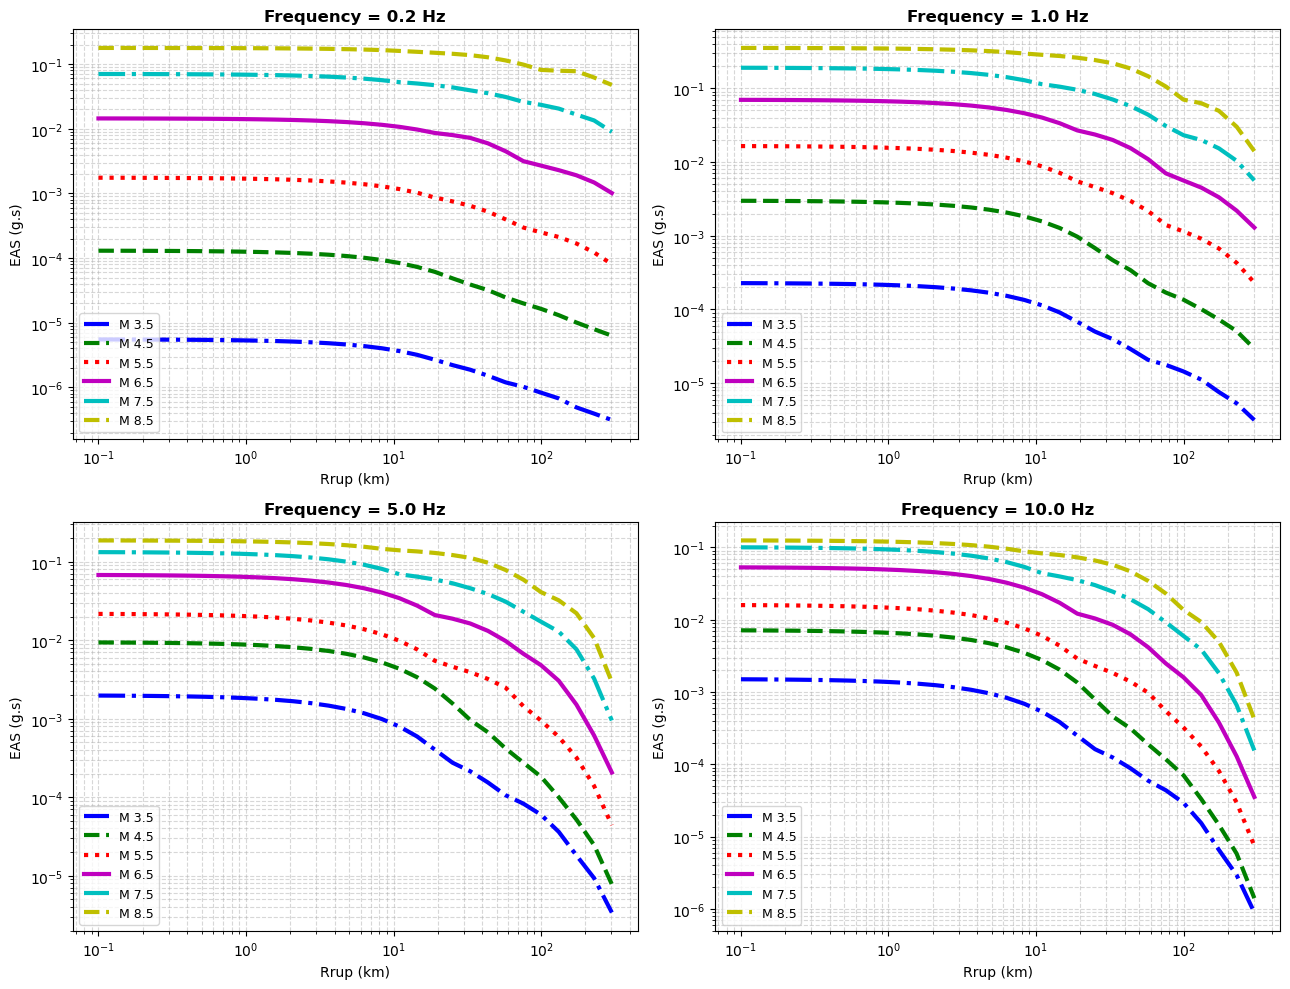

In [9]:
# ----------------------------------------------------------
# Input parameters
# ----------------------------------------------------------
magnitudes = [3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
freqs_to_plot = [0.2, 1.0, 5.0, 10.0]
Rrups = np.logspace(-1, 2.48, 30)   # 0.1 to 300 km

# ----------------------------------------------------------
# Start figure with 4 subplots
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, freq in zip(axes, freqs_to_plot):

    # Find nearest frequency index in the multi-output model
    idx = np.argmin(np.abs(freqs - freq))
    freq_effective = freqs[idx]

    # If you want, you can warn when requested freq != effective freq
    if not np.isclose(freq_effective, freq, rtol=1e-3, atol=1e-6):
        print(f"Requested freq {freq} Hz; using nearest freq {freq_effective} Hz (index {idx})")

    for M, color, ls in zip(magnitudes, colors, line_styles):

        # Build input matrix for all Rrups at this M
        # Shape: (n_Rrups, 6) matching [magnitude, dip, ztor, vs30, z2p5_preferred, rrup]
        X = np.column_stack([
            np.full_like(Rrups, M, dtype=float),  # magnitude
            np.full_like(Rrups, DIP_REF, dtype=float),
            np.full_like(Rrups, ZTOR_REF, dtype=float),
            np.full_like(Rrups, VS30_REF, dtype=float),
            np.full_like(Rrups, Z2P5_REF, dtype=float),
            Rrups.astype(float)
        ])

        # Scale inputs
        X_scaled = scaler.transform(X)

        # NOTE: multi_model predicts ln(EAS) for ALL frequencies at once
        # Shape: (n_Rrups, n_freqs)
        pred_ln_all = model.predict(X_scaled, verbose=0)

        # Take the column corresponding to this frequency index
        pred_ln = pred_ln_all[:, idx]

        # Convert back to normal EAS
        preds = np.exp(pred_ln)

        ax.loglog(Rrups, preds, ls, color=color, label=f"M {M}", linewidth=3)

    ax.set_title(f"Frequency = {freq} Hz", fontsize=12, fontweight="bold")
    ax.set_xlabel("Rrup (km)")
    ax.set_ylabel("EAS (g.s)")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()


fig.savefig('Distance scaling.pdf', bbox_inches="tight")
fig.savefig('Distance scaling.png', bbox_inches="tight", dpi=300)

# Magnitude scaling

Requested freq 0.2 Hz; using nearest freq 0.204174 Hz (index 5)
Requested freq 5.0 Hz; using nearest freq 5.011872 Hz (index 16)


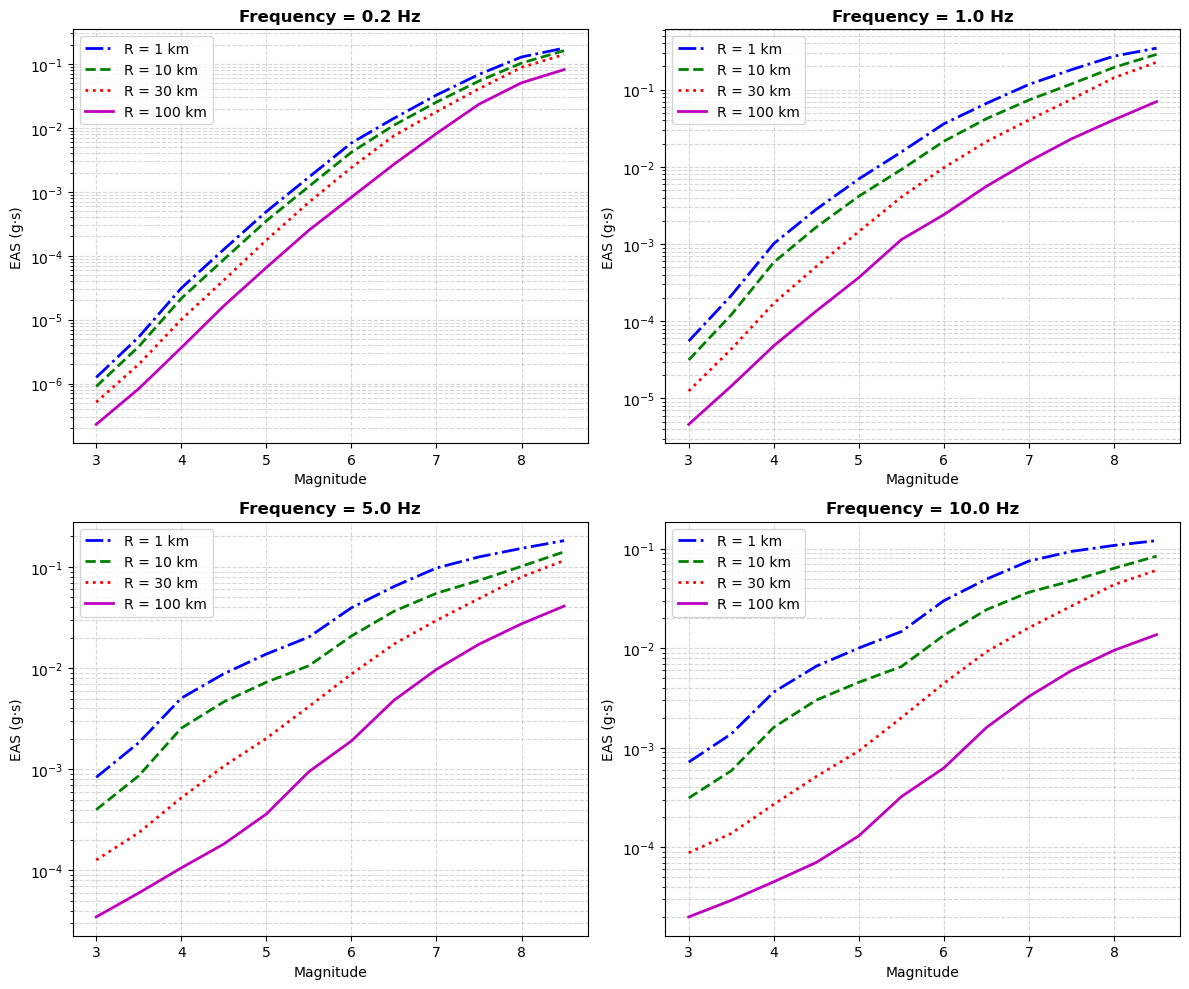

In [11]:
# ----------------------------------------------------------
# Inputs
# ----------------------------------------------------------
magnitudes     = [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5]
distances      = [1, 10, 30, 100]
freqs_to_plot  = [0.2, 1.0, 5.0, 10.0]

# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, freq in zip(axes, freqs_to_plot):

    # Find nearest frequency index in the multi-output model
    idx = np.argmin(np.abs(freqs - freq))
    freq_effective = freqs[idx]

    # Optional: notify if requested freq != used freq
    if not np.isclose(freq_effective, freq, rtol=1e-3, atol=1e-6):
        print(f"Requested freq {freq} Hz; using nearest freq {freq_effective} Hz (index {idx})")

    # ANN line style from GMM_styles
    style_ann = GMM_styles["This study"]

    for R, color, ls in zip(distances, colors, line_styles):

        # Build input matrix for all magnitudes at this R
        # Shape: (n_magnitudes, 6) matching [magnitude, dip, ztor, vs30, z2p5_preferred, rrup]
        X = np.column_stack([
            np.array(magnitudes, dtype=float),                # magnitude varies
            np.full(len(magnitudes), DIP_REF,   dtype=float), # dip
            np.full(len(magnitudes), ZTOR_REF,  dtype=float), # ztor
            np.full(len(magnitudes), VS30_REF,  dtype=float), # vs30
            np.full(len(magnitudes), Z2P5_REF,  dtype=float), # z2p5_preferred
            np.full(len(magnitudes), R,         dtype=float)  # fixed Rrup
        ])


        # Scale inputs with the same scaler used in training
        X_scaled = scaler.transform(X)

        # multi_model predicts ln(EAS) for ALL frequencies at once
        # Shape: (n_magnitudes, n_freqs)
        ln_pred_all = model.predict(X_scaled, verbose=0)

        # Take the column for this frequency index and exponentiate
        ln_pred = ln_pred_all[:, idx]
        preds   = np.exp(ln_pred)

        ax.semilogy(
            magnitudes,
            preds,
            linestyle=ls,
            linewidth=2,
            color=color,
            label=f"R = {R} km"
        )

    ax.set_title(f"Frequency = {freq} Hz", fontsize=12, fontweight="bold")
    ax.set_xlabel("Magnitude")
    ax.set_ylabel("EAS (g·s)")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

plt.tight_layout()

fig.savefig('Magnitude scaling.pdf', bbox_inches="tight")
fig.savefig('Magnitude scaling.png', bbox_inches="tight", dpi=300)